In [3]:
import pandas as pd
import plotly.express as px
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# === Carregar o arquivo do Cepea ===
cepea = pd.read_excel('../data/Boi_gordo_corrigido.xlsx', engine='openpyxl')

# Renomear coluna "Valor" para "Preco_Arroba" 
cepea = cepea.rename(columns={'Valor': 'Preco_Arroba'})

# Converter Data com formato brasileiro 
cepea['Data'] = pd.to_datetime(cepea['Data'], dayfirst=True, errors='coerce')

# Limpeza do preço 
cepea['Preco_Arroba'] = (
    cepea['Preco_Arroba']
    .astype(str)
    .str.replace(r'R\$', '', regex=True)
    .str.replace(',', '.', regex=False)
    .str.replace('-', '', regex=False)
    .str.replace(' ', '', regex=False)
    .str.strip()
)

cepea['Preco_Arroba'] = pd.to_numeric(cepea['Preco_Arroba'], errors='coerce')
cepea = cepea.dropna(subset=['Preco_Arroba', 'Data'])

# Ordenar
cepea = cepea.sort_values('Data').reset_index(drop=True)

print(f"✅ Dados carregados e limpos: {cepea.shape[0]} linhas")
print(f"Período: {cepea['Data'].min().date()} até {cepea['Data'].max().date()}")
print(f"Último preço: R$ {cepea['Preco_Arroba'].iloc[-1]:.2f}")
cepea.head()

✅ Dados carregados e limpos: 2525 linhas
Período: 2016-01-04 até 2026-03-23
Último preço: R$ 354.91


,Data,Preco_Arroba
0,2016-01-04,150.00
1,2016-01-05,150.00
2,2016-01-06,148.81
3,2016-01-07,148.21
4,2016-01-08,148.46


In [4]:
# Preparar dados para o Prophet
df_prophet = cepea[['Data', 'Preco_Arroba']].copy()
df_prophet.columns = ['ds', 'y']  

# Criar e treinar o modelo
modelo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
modelo.fit(df_prophet)

print("✅ Modelo Prophet treinado com sucesso!")

13:38:39 - cmdstanpy - INFO - Chain [1] start processing
13:38:40 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo Prophet treinado com sucesso!


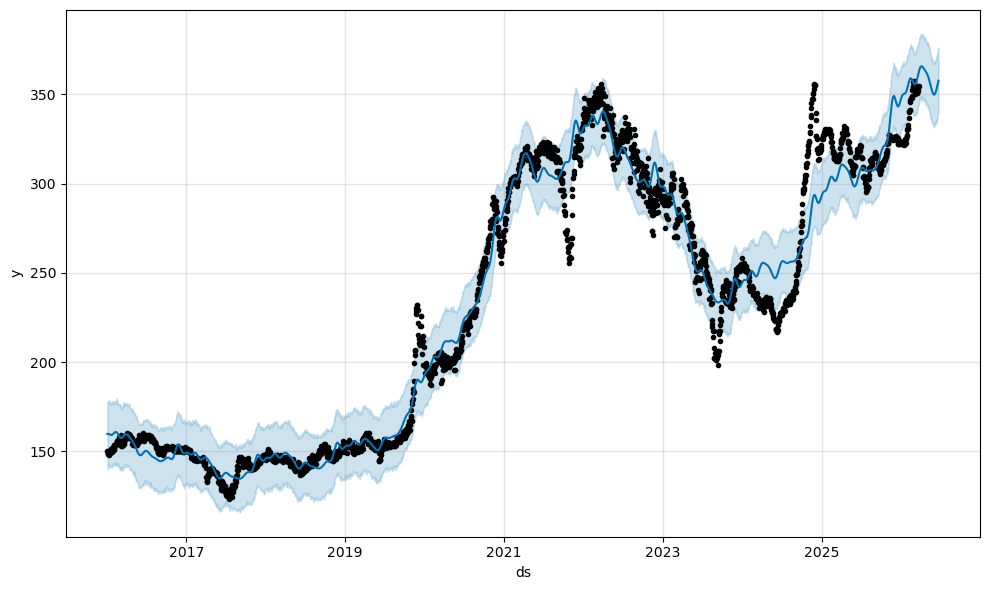

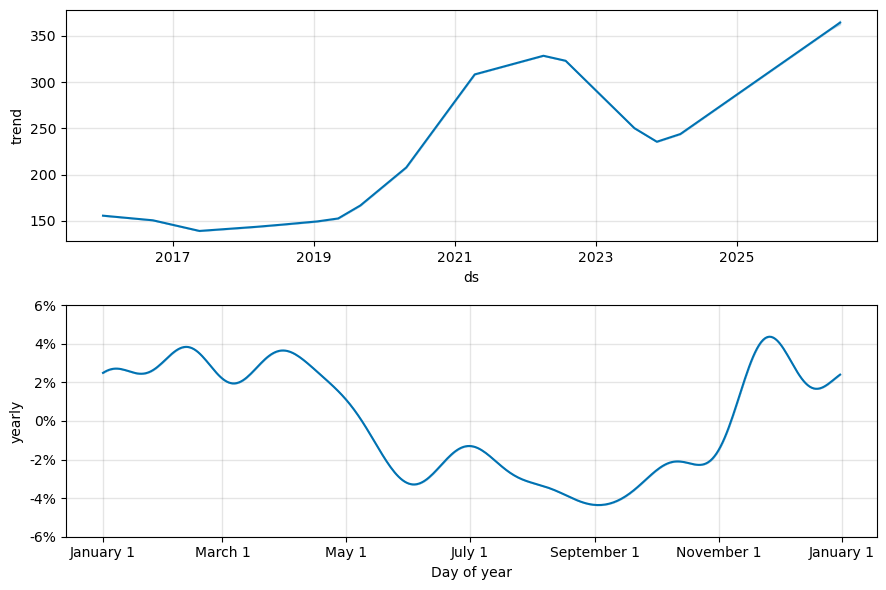

In [5]:
# Fazer previsão para os próximos 90 dias
futuro = modelo.make_future_dataframe(periods=90)
previsao = modelo.predict(futuro)

# Gráfico da previsão
fig_previsao = modelo.plot(previsao)
fig_previsao.show()

# Componentes (tendência + sazonalidade)
fig_componentes = modelo.plot_components(previsao)
fig_componentes.show()

In [6]:
# Calculadora interativa para o produtor
def estimar_valor_animal(peso_vivo, rendimento=0.50):
    arrobas = (peso_vivo * rendimento) / 15
    preco_atual = cepea['Preco_Arroba'].iloc[-1]
    valor = arrobas * preco_atual
    return round(arrobas, 2), round(valor, 2)

# Teste
peso = 510
arrobas, valor = estimar_valor_animal(peso)
print(f"🐂 Boi de {peso} kg → {arrobas} arrobas → R$ {valor}")

🐂 Boi de 510 kg → 17.0 arrobas → R$ 6033.47


In [7]:
# Preço previsto para daqui a 30 dias
ultima_data = previsao['ds'].iloc[-1]
preco_previsto_30d = previsao[previsao['ds'] == ultima_data - pd.Timedelta(days=60)]['yhat'].values[0]  # ajuste se necessário
print(f"🔮 Previsão para os próximos 30 dias: cerca de R$ {preco_previsto_30d:.2f} por arroba")

🔮 Previsão para os próximos 30 dias: cerca de R$ 363.11 por arroba
